In [10]:
import pandas as pd

excel_file_name = './Employee_Projects.xlsx'

df_excel = pd.read_excel(excel_file_name)

display(df_excel.head())

,EmpId,EmployeeName,Gender,Age,Department,Salary,YearOfExperince,Position,NumberOfProject
0,1,Employee1,Male,48,Management,500000,15,CEO,30
1,2,Employee2,Female,35,HR,100000,15,HR Manager,25
2,3,Employee3,Male,25,Engineering,150000,10,Engineer,10
3,4,Employee4,Male,25,Engineering,150000,10,Engineer,10
4,5,Employee5,Male,25,Engineering,150000,10,Engineer,10


### Analysis Task 1: Determine the distribution of employees across each team and calculate the percentage split


In [14]:
# Calculate the number of employees per team
team_distribution = df_excel['Department'].value_counts()

# Calculate the total number of employees
total_employees = len(df_excel)

# Calculate the percentage split for each team
team_percentage = (team_distribution / total_employees) * 100

# Combine the results into a DataFrame for better display
df_team_distribution = pd.DataFrame({
    'Number of Employees': team_distribution,
    'Percentage (%)': team_percentage
})

display(df_team_distribution)

,Number of Employees,Percentage (%)
Department,,
Engineering,213,46.506550
IT,157,34.279476
Finance,35,7.641921
Admin&Operations,18,3.930131
Logistics,18,3.930131
HR,9,1.965066
Security,7,1.528384
Management,1,0.218341


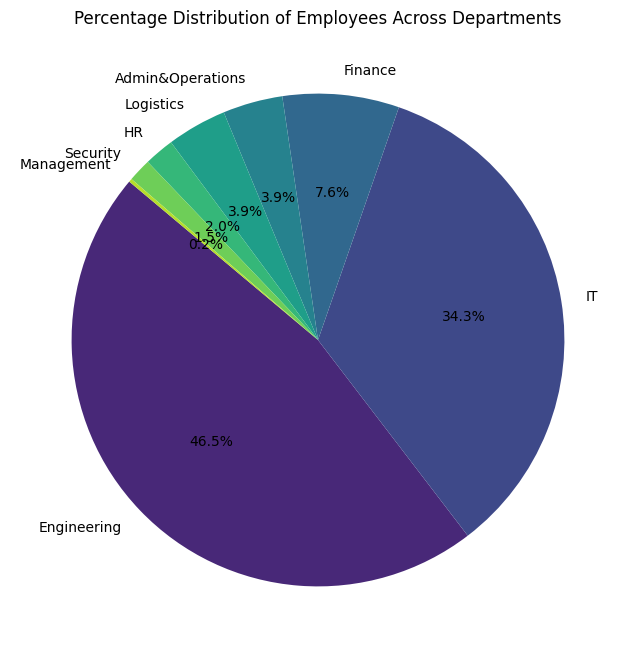

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
labels = df_team_distribution.index
sizes = df_team_distribution['Percentage (%)']

fig = plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(labels)))
plt.title('Percentage Distribution of Employees Across Departments')
plt.show()

### Analysis Task 2: Segregate employees based on their positions (Departments)

In [21]:
# Segregate employees by Department (position)
employees_by_department = df_excel['Department'].value_counts().reset_index()
employees_by_department.columns = ['Department', 'Number of Employees']

display(employees_by_department)

,Department,Number of Employees
0,Engineering,213
1,IT,157
2,Finance,35
3,Admin&Operations,18
4,Logistics,18
5,HR,9
6,Security,7
7,Management,1


### Analysis Task 3: Identify the predominant age group

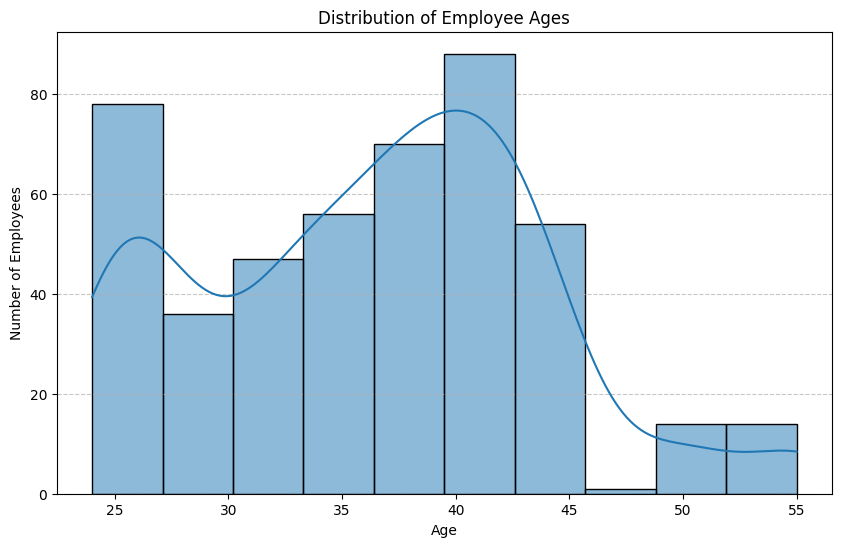

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_excel['Age'], bins=10, kde=True)
plt.title('Distribution of Employee Ages')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [24]:
# Calculate the mode to find the single most frequent age
predominant_age_mode = df_excel['Age'].mode()
print(f"The single most frequent age is: {predominant_age_mode.to_list()}")

# Group ages into bins to find predominant age group
age_bins = [18, 25, 35, 45, 55, 65, 75] # Define age bins
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74']

df_excel['AgeGroup'] = pd.cut(df_excel['Age'], bins=age_bins, labels=age_labels, right=False)
predominant_age_group = df_excel['AgeGroup'].value_counts().idxmax()

print(f"The predominant age group is: {predominant_age_group}")
display(df_excel['AgeGroup'].value_counts().sort_index())

The single most frequent age is: [42]
The predominant age group is: 35-44


,count
AgeGroup,
18-24,14
25-34,165
35-44,232
45-54,33
55-64,14
65-74,0


### Analysis Task 4: Discovering which department has the highest salary expenditure

In [25]:
# Calculate total salary expenditure per department
salary_expenditure_by_department = df_excel.groupby('Department')['Salary'].sum().sort_values(ascending=False)

print("Total Salary Expenditure per Department:")
display(salary_expenditure_by_department)

# Identify the department with the highest salary expenditure
highest_expenditure_department = salary_expenditure_by_department.idxmax()
highest_expenditure_amount = salary_expenditure_by_department.max()

print(f"\nThe department with the highest salary expenditure is '{highest_expenditure_department}' with a total of ${highest_expenditure_amount:,.2f}.")

Total Salary Expenditure per Department:


,Salary
Department,
Engineering,30600000
Finance,7000000
IT,2355000
Admin&Operations,2160000
Logistics,1440000
HR,860000
Management,500000
Security,350000



The department with the highest salary expenditure is 'Engineering' with a total of $30,600,000.00.


/tmp/ipykernel_1492/506453971.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salary_expenditure_by_department.index, y=salary_expenditure_by_department.values, palette='viridis')


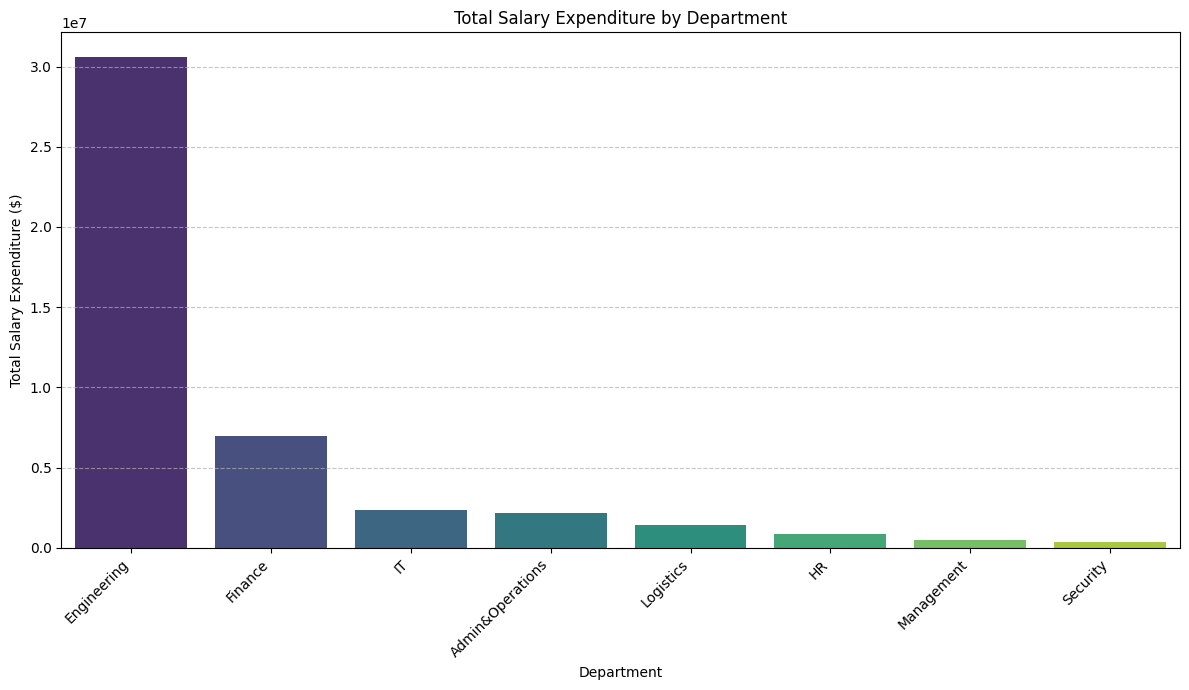

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=salary_expenditure_by_department.index, y=salary_expenditure_by_department.values, palette='viridis')
plt.title('Total Salary Expenditure by Department')
plt.xlabel('Department')
plt.ylabel('Total Salary Expenditure ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analysis Task 5: Investigate the correlation between age and salary, and visualize it.

The correlation coefficient between Age and Salary is: -0.05


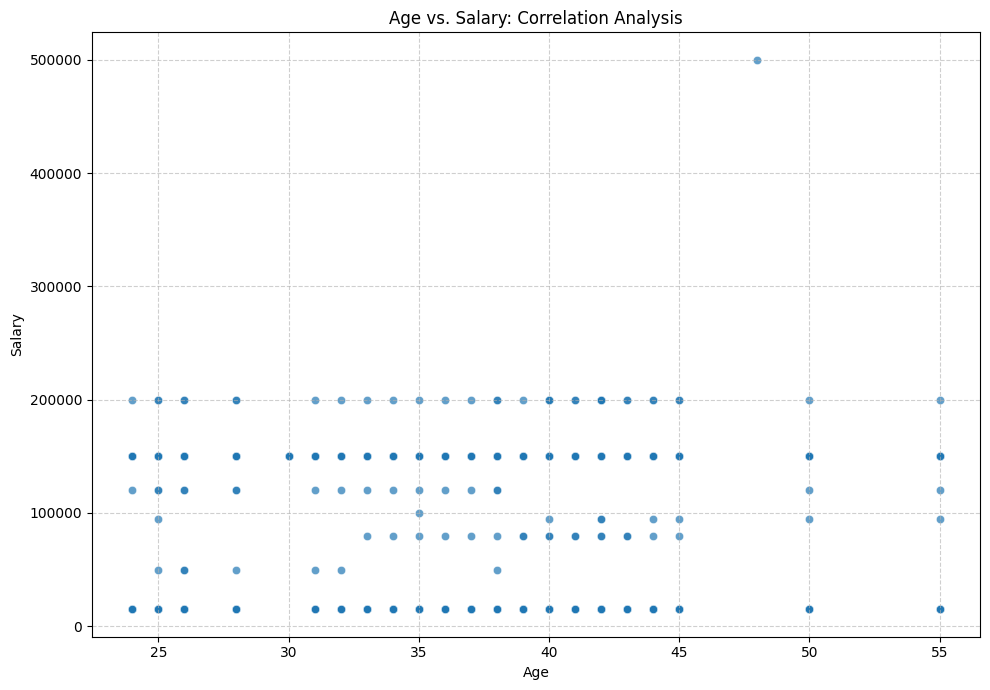

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation between Age and Salary
age_salary_correlation = df_excel['Age'].corr(df_excel['Salary'])

print(f"The correlation coefficient between Age and Salary is: {age_salary_correlation:.2f}")

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age', y='Salary', data=df_excel, alpha=0.7)
plt.title('Age vs. Salary: Correlation Analysis')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()